Clustering GMM MCA

C:\Users\nouam\AppData\Local\Temp\ipykernel_6820\3627331047.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap4 = cm.get_cmap("tab10", 4)


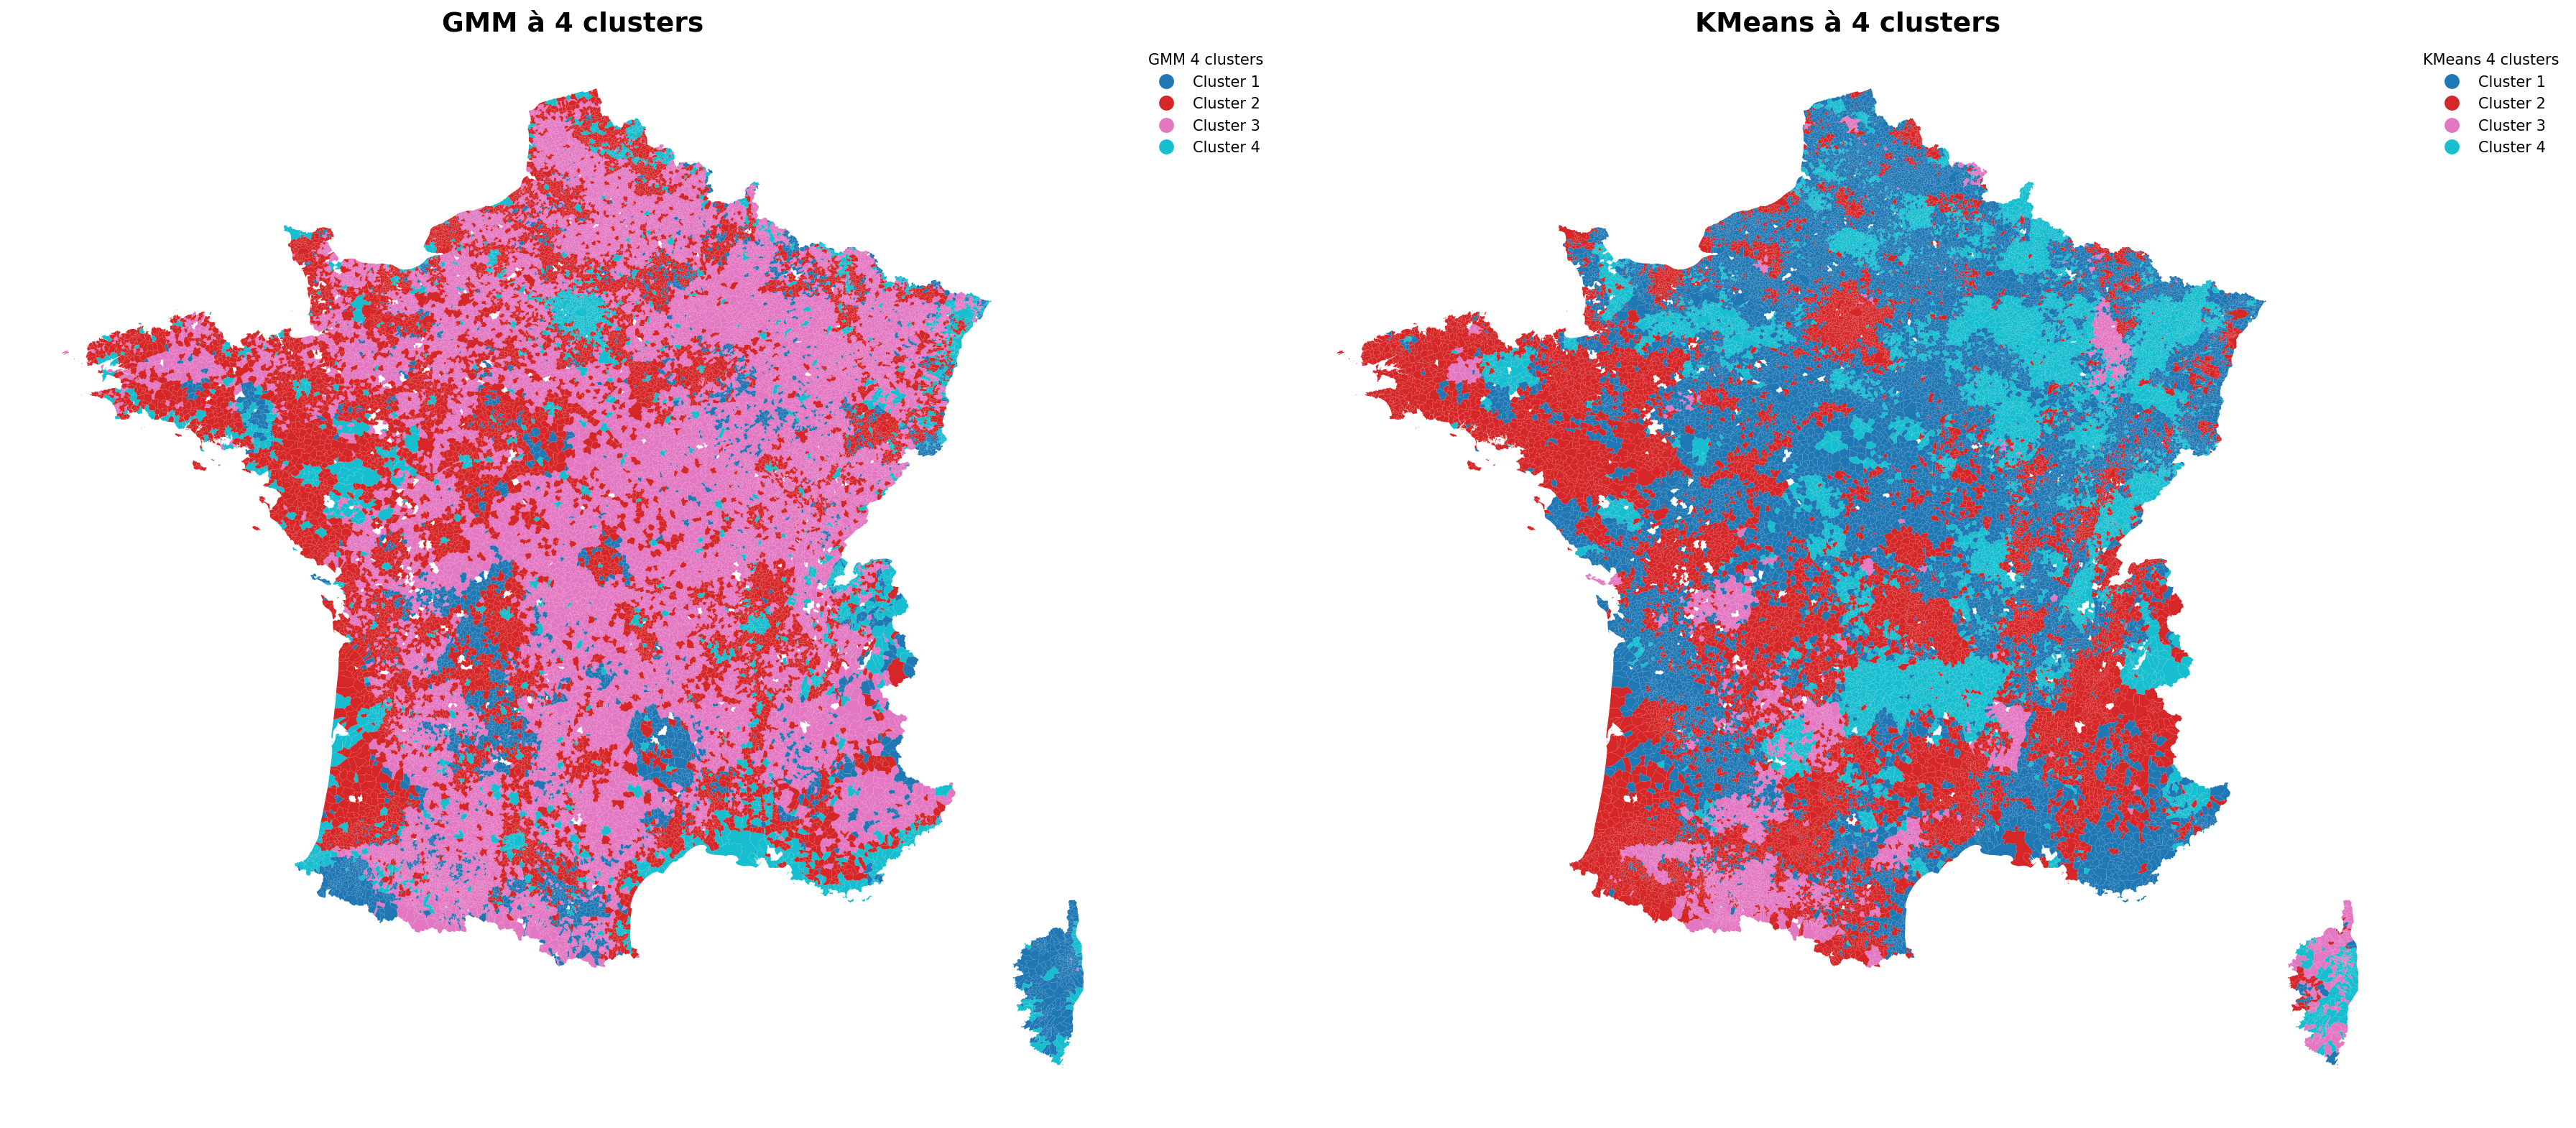

In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df_travail = pd.read_parquet("data_util.parquet")

# Préparation des données numériques pour le clustering
df_numerique4 = (
    df_travail.select_dtypes(include=[np.number])
    .replace([np.inf, -np.inf], np.nan)
    .fillna(df_travail.select_dtypes(include=[np.number]).median())
)

scaler4 = StandardScaler()
X4 = pd.DataFrame(
    scaler4.fit_transform(df_numerique4),
    columns=df_numerique4.columns,
    index=df_numerique4.index,
)

# GMM 4 clusters
gmm4 = GaussianMixture(n_components=4, covariance_type="full", random_state=42)
labels_gmm4 = gmm4.fit_predict(X4) + 1

# KMeans 4 clusters
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans4 = kmeans4.fit_predict(X4) + 1

# Préparation des tables pour la carte
df_gmm_map_4 = df_travail.reset_index()
df_kmeans_map_4 = df_travail.reset_index()

df_gmm_map_4["codecommune"] = df_gmm_map_4["codecommune"].astype(str).str.zfill(5)
df_kmeans_map_4["codecommune"] = df_kmeans_map_4["codecommune"].astype(str).str.zfill(5)

df_gmm_map_4["Nom_Cluster_GMM4"] = "Cluster " + labels_gmm4.astype(str)
df_kmeans_map_4["Nom_Cluster_KMeans4"] = "Cluster " + labels_kmeans4.astype(str)

if "france_communes" not in globals():
    france_communes = gpd.read_file(
        "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
    )

carte_gmm_4 = france_communes.merge(
    df_gmm_map_4, left_on="code", right_on="codecommune", how="inner"
)
carte_kmeans_4 = france_communes.merge(
    df_kmeans_map_4, left_on="code", right_on="codecommune", how="inner"
)

fig, axes = plt.subplots(1, 2, figsize=(24, 14), dpi=150)

categories_gmm4 = sorted(carte_gmm_4["Nom_Cluster_GMM4"].unique())
categories_kmeans4 = sorted(carte_kmeans_4["Nom_Cluster_KMeans4"].unique())
cmap4 = cm.get_cmap("tab10", 4)

carte_gmm_4.plot(
    column="Nom_Cluster_GMM4",
    ax=axes[0],
    categorical=True,
    categories=categories_gmm4,
    cmap=cmap4,
    legend=True,
    linewidth=0,
    edgecolor="none",
    legend_kwds={
        "title": "GMM 4 clusters",
        "loc": "upper left",
        "bbox_to_anchor": (1, 1),
        "frameon": False,
    },
)
axes[0].set_axis_off()
axes[0].set_title("GMM à 4 clusters", fontsize=18, fontweight="bold")

carte_kmeans_4.plot(
    column="Nom_Cluster_KMeans4",
    ax=axes[1],
    categorical=True,
    categories=categories_kmeans4,
    cmap=cmap4,
    legend=True,
    linewidth=0,
    edgecolor="none",
    legend_kwds={
        "title": "KMeans 4 clusters",
        "loc": "upper left",
        "bbox_to_anchor": (1, 1),
        "frameon": False,
    },
)
axes[1].set_axis_off()
axes[1].set_title("KMeans à 4 clusters", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
import prince  # pip install prince
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# ── 1. Means dans l'espace original (non standardisé) ──────────────────────

# GMM : moyennes directes des composantes
means_gmm_original = pd.DataFrame(
    scaler4.inverse_transform(gmm4.means_),
    columns=df_numerique4.columns,
    index=[f"GMM_Cluster_{i+1}" for i in range(gmm4.n_components)],
)

# KMeans : centres dans l'espace standardisé → inverse transform
means_kmeans_original = pd.DataFrame(
    scaler4.inverse_transform(kmeans4.cluster_centers_),
    columns=df_numerique4.columns,
    index=[f"KMeans_Cluster_{i+1}" for i in range(kmeans4.n_clusters)],
)

print("=== Means GMM (espace original) ===")
print(means_gmm_original.round(3))
print("\n=== Means KMeans (espace original) ===")
print(means_kmeans_original.round(3))


#Il faut prendre les means ici, puis les ajouter aux individus pour les projeter dans l'espace MCA, et ensuite faire la carte

=== Means GMM (espace original) ===
               pvoixAUG  pvoixNUP  pvoixDVG  pvoixECO  pvoixREG  pvoixENS  \
GMM_Cluster_1     0.011     0.186     0.056     0.022     0.096     0.187   
GMM_Cluster_2     0.012     0.226     0.026     0.023     0.008     0.241   
GMM_Cluster_3     0.012     0.203     0.049     0.019     0.011     0.212   
GMM_Cluster_4     0.011     0.250     0.025     0.030     0.032     0.254   

               pvoixUDI  pvoixLR  pvoixDVD  pvoixREC  ...  peretr2022  \
GMM_Cluster_1     0.050    0.098     0.057     0.039  ...       0.410   
GMM_Cluster_2     0.035    0.113     0.026     0.038  ...       0.230   
GMM_Cluster_3     0.000    0.151     0.056     0.037  ...       0.226   
GMM_Cluster_4     0.018    0.092     0.052     0.045  ...       0.567   

               perimmigre2022  perpropri2022  perprive2021comm  revratio2022  \
GMM_Cluster_1           0.385          0.822             0.348         0.869   
GMM_Cluster_2           0.230          0.794        

In [ ]:
# ── 2. MCA sur df_travail (variables catégorielles) ────────────────────────

# Sélection des colonnes catégorielles
df_cat = df_travail.select_dtypes(include=["object", "category"])

if df_cat.empty:
    raise ValueError("Aucune variable catégorielle trouvée dans df_travail.")

# Ajustement de la MCA
mca = prince.MCA(n_components=2, random_state=42)
mca.fit(df_cat)

# Coordonnées des modalités (colonnes)
coords_modalites = mca.column_coordinates(df_cat)

# ── 3. Projection des means sur la MCA (individuals supplémentaires) ────────
# On recentre les means sur les mêmes colonnes catégorielles... 
# MAIS les means sont numériques : on les projette via les colonnes numériques
# en utilisant la corrélation rang (eta²) ou un biplots numérique.
# 
# Approche recommandée : MCA + projection des means comme individus 
# supplémentaires en les discrétisant avec les mêmes bins que df_travail.

# Discrétisation des variables numériques de df_travail (pour la MCA mixte)
df_num = df_travail.select_dtypes(include=[np.number])
n_bins = 4

df_num_disc = pd.DataFrame(index=df_travail.index)
bin_edges = {}  # on sauvegarde les bins pour discrétiser les means

for col in df_num.columns:
    series = df_num[col].replace([np.inf, -np.inf], np.nan).dropna()
    try:
        _, edges = pd.qcut(series, q=n_bins, retbins=True, duplicates="drop")
        df_num_disc[col] = pd.cut(
            df_num[col], bins=edges, labels=False, include_lowest=True
        ).astype("Int64").astype(str)
        bin_edges[col] = edges
    except Exception:
        pass  # ignore si trop peu de valeurs uniques

# MCA sur variables discrétisées (+ catégorielles si présentes)
df_mca_input = df_num_disc.copy()
if not df_cat.empty:
    df_mca_input = pd.concat([df_num_disc, df_cat.astype(str)], axis=1)

df_mca_input = df_mca_input.fillna("NA")

mca2 = prince.MCA(n_components=2, random_state=42)
mca2.fit(df_mca_input)

coords_individus = mca2.row_coordinates(df_mca_input)
coords_modalites2 = mca2.column_coordinates(df_mca_input)


# ── 4. Discrétisation des means pour projection ────────────────────────────

def discretiser_means(means_df, bin_edges_dict, df_cat_original=None):
    """Discrétise un DataFrame de means avec les mêmes bins que l'entraînement."""
    result = pd.DataFrame(index=means_df.index)
    for col in means_df.columns:
        if col in bin_edges_dict:
            result[col] = pd.cut(
                means_df[col],
                bins=bin_edges_dict[col],
                labels=False,
                include_lowest=True,
            ).astype("Int64").astype(str).fillna("NA")
    return result

means_gmm_disc = discretiser_means(means_gmm_original, bin_edges)
means_kmeans_disc = discretiser_means(means_kmeans_original, bin_edges)

# Alignement des colonnes
for col in df_mca_input.columns:
    if col not in means_gmm_disc.columns:
        means_gmm_disc[col] = "NA"
    if col not in means_kmeans_disc.columns:
        means_kmeans_disc[col] = "NA"

means_gmm_disc = means_gmm_disc[df_mca_input.columns]
means_kmeans_disc = means_kmeans_disc[df_mca_input.columns]

# Projection (transform = coordonnées supplémentaires)
coords_gmm_proj = mca2.row_coordinates(means_gmm_disc)
coords_kmeans_proj = mca2.row_coordinates(means_kmeans_disc)

print("\n=== Coordonnées MCA — Means GMM ===")
print(coords_gmm_proj.round(4))
print("\n=== Coordonnées MCA — Means KMeans ===")
print(coords_kmeans_proj.round(4))


# ── 5. Visualisation du biplot MCA + projections ──────────────────────────

fig, ax = plt.subplots(figsize=(14, 10))

# Nuage des individus (grisé, sous-échantillonné pour la lisibilité)
sample_idx = np.random.choice(len(coords_individus), size=min(3000, len(coords_individus)), replace=False)
ax.scatter(
    coords_individus.iloc[sample_idx, 0],
    coords_individus.iloc[sample_idx, 1],
    alpha=0.07, s=4, color="lightgrey", zorder=1,
)

# Modalités
ax.scatter(
    coords_modalites2.iloc[:, 0],
    coords_modalites2.iloc[:, 1],
    alpha=0.5, s=20, color="steelblue", zorder=2, label="Modalités"
)
for idx, row in coords_modalites2.iterrows():
    ax.annotate(str(idx), (row.iloc[0], row.iloc[1]),
                fontsize=6, alpha=0.6, color="steelblue",
                xytext=(3, 3), textcoords="offset points")

# Means GMM
colors_gmm = plt.cm.Reds(np.linspace(0.4, 0.9, len(coords_gmm_proj)))
for i, (idx, row) in enumerate(coords_gmm_proj.iterrows()):
    ax.scatter(row.iloc[0], row.iloc[1], s=180, color=colors_gmm[i],
               marker="D", zorder=5, edgecolors="black", linewidths=0.8)
    ax.annotate(idx, (row.iloc[0], row.iloc[1]),
                fontsize=9, fontweight="bold", color=colors_gmm[i],
                xytext=(6, 6), textcoords="offset points")

# Means KMeans
colors_km = plt.cm.Greens(np.linspace(0.4, 0.9, len(coords_kmeans_proj)))
for i, (idx, row) in enumerate(coords_kmeans_proj.iterrows()):
    ax.scatter(row.iloc[0], row.iloc[1], s=180, color=colors_km[i],
               marker="^", zorder=5, edgecolors="black", linewidths=0.8)
    ax.annotate(idx, (row.iloc[0], row.iloc[1]),
                fontsize=9, fontweight="bold", color=colors_km[i],
                xytext=(6, 6), textcoords="offset points")

# Axes
ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

# Variance expliquée
ev = mca2.explained_inertia_
ax.set_xlabel(f"Dim 1 ({ev[0]*100:.1f}% inertie)", fontsize=12)
ax.set_ylabel(f"Dim 2 ({ev[1]*100:.1f}% inertie)", fontsize=12)
ax.set_title("Biplot MCA — Projection des centres de clusters", fontsize=14, fontweight="bold")

legend_elements = [
    mpatches.Patch(color="steelblue", alpha=0.6, label="Modalités MCA"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="tomato",
               markersize=10, markeredgecolor="black", label="Means GMM"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="mediumseagreen",
               markersize=10, markeredgecolor="black", label="Means KMeans"),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=True)
plt.tight_layout()
plt.show()